# Fashion MNIST Classification

# Import required libraries and background

The **os module** provides functions to interact with the operating system, e.g., creating directories, joining paths, listing files.

The **matplotlib.pyplot** is a library for plotting graphs and images. You can use plt.imshow() to visualize images, or plt.plot() for charts.

PIL (Python Imaging Library)
* **Image**: helps in loading and saving images.
* **ImageOps**: provides various operations on images, like flipping, adding borders, converting to grayscale, etc.

We are loading the **Fashion MNIST** dataset. Fashion MNIST is a dataset of 70,000 grayscale images of clothing items in 10 categories. It is a popular dataset for testing image classification algorithms.

**Sequential** is a linear stack of layers model. We will use it to build a CNN model.


**load_model** is used to load a saved model from disk (.h5 file).

These are the layers used in a Convolutional Neural Network (CNN):

* **Conv2D**: Convolutional layer — extracts spatial features from images.

* **MaxPooling2D**: Reduces spatial dimensions — makes model faster and helps generalization.

* **Flatten**: Flattens the 2D feature maps into a 1D vector for the dense layer.

* **Dense**: Fully connected layer — used for classification.

* **Dropout**: Randomly drops some neurons during training to prevent overfitting.

**Utils** and **to_categorical** will be used to converts integer class labels (0-9) to one-hot encoded vectors, which are required for training the neural network.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Setup the directories for training and testing

In [ ]:
# Setup directories and parameters
# Directory name where image files could be stored (if you save images later).

base_dir = "fashion_mnist_images"

# Creates subdirectories for training and testing images.
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

# Path where the trained model will be saved or loaded from.
model_path = "fashion_mnist_model.h5"

# Class names (Human-readable labels)
# List of class names corresponding to the labels (0 to 9).
# For example: label 0 → "T-shirt_top", label 1 → "Trouser", etc.
class_names = [
    "T-shirt_top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle_boot"
]

Loads the Fashion MNIST dataset:
* x_train → training images (60,000 images of shape 28x28).
* y_train → labels for training images (integers from 0 to 9).
* x_test → test images (10,000 images of shape 28x28).
* y_test → labels for test images.

In [ ]:
# === Load and preprocess dataset ===
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

We reshape the images to add a channel dimension (needed for CNN input):
* Original shape: (num_samples, 28, 28)
* After reshape: (num_samples, 28, 28, 1) → last dimension is channel = 1 (grayscale).
* Converts pixel values to float32 type and normalizes pixel values to range [0, 1]: Originally pixels are 0-255 → dividing by 255.0 brings them to 0-1, which helps training.

In [ ]:
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0


In [ ]:
# === Save images to folders ===
print("Saving dataset images...")
for split, data, labels, path in [("train", x_train, y_train, train_dir), ("test", x_test, y_test, test_dir)]:
    for class_name in class_names:
        os.makedirs(os.path.join(path, class_name), exist_ok=True)
    for idx, (img, label) in enumerate(zip(data, labels)):
        class_folder = os.path.join(path, class_names[label])
        filename = os.path.join(class_folder, f"{split}_{idx}.png")
        img_reshaped = (img.reshape(28, 28) * 255).astype(np.uint8)
        Image.fromarray(img_reshaped).save(filename)
print(f"Images saved under: {base_dir}")

Saving dataset images...
Images saved under: fashion_mnist_images


In [ ]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Create the model

You're creating a Sequential model, meaning layers will be stacked one after another.

The model will process the image through a sequence of layers.

* **Conv2D**: First convolution layer. 32 filters → this layer will produce 32 feature maps. (3,3) → size of each filter = 3x3.

* **activation='relu'** → apply ReLU activation (Rectified Linear Unit) to introduce non-linearity. input_shape=(28,28,1) → expects images of size 28x28, 1 channel (grayscale).

* **MaxPooling**: Downsamples feature maps by taking the maximum in each 2x2 window. Reduces spatial size → helps reduce the number of parameters and prevents overfitting.

* **Second Conv2D layer**: 64 filters → produces 64 feature maps. Each filter is 3x3. Activation is again ReLU.
    
* **MaxPooling**: Again applies 2x2 max pooling to reduce spatial dimensions.

* **Flatten()**: Converts the 2D feature maps into a 1D vector. Example: if after pooling you have feature maps of shape (7,7,64), Flatten will reshape it into a vector of size 7*7*64 = 3136.

* **Dense()**: Fully connected layer with 128 neurons. Each neuron is connected to all the outputs of the previous layer Activation is ReLU.

* **Dropout layer**: During training, it randomly sets 50% of its inputs to zero. Helps prevent overfitting (forces the model not to rely too much on any one neuron).
    
* **Output Layer**: Final dense layer → output layer. 10 neurons → one for each of the 10 classes. Activation is softmax. Softmax turns the outputs into probabilities (values between 0 and 1). The sum of all 10 probabilities = 1. The class with the highest probability will be the model’s prediction.

Paremeters used for the compilation of the model:

* **optimizer='adam'**: Adam is an advanced optimizer that adjusts learning rates dynamically. Generally performs very well on deep learning tasks.
    
* **loss='categorical_crossentropy'**: Since this is a multi-class classification problem and we used one-hot encoding, we use categorical_crossentropy loss.
    
* **metrics=['accuracy']**: We ask the model to report the accuracy metric while training/evaluating.

In [ ]:
# === Define model ===
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Define the desired learning rate
learning_rate = 0.0001  # You can change this value

# Create an Adam optimizer with the specified learning rate

optimizer = Adam(learning_rate=learning_rate)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Visualize the model

# Train the model

**model.fit() function**
    
This is the function that trains the model on your data.

It takes the training data (x_train, y_train_cat) and runs through the neural network multiple times, updating weights to minimize the loss.

Your training images:

* **Shape**: (60000, 28, 28, 1) → 60,000 images of size 28x28 pixels, with 1 channel (grayscale). Your training labels — one-hot encoded: Shape: (60000, 10) For each image, the label is a vector of 10 values → one-hot encoded: Example: class 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0].

* **Epoch**: An epoch = 1 full pass over the entire training dataset. epochs=5 → the model will go through the full training data 5 times.
      
  Why multiple epochs? One pass is usually not enough to optimize the model. With each pass, the model can gradually improve by adjusting weights.

* **Batch Size**: The model does NOT update weights after seeing every individual image → instead, it updates them in batches.
      
  A batch = small group of samples processed together.
      
  batch_size=64 → the model will look at 64 images at a time, calculate gradients, and update weights.

  Tradeoff: Smaller batch size → more updates → potentially better generalization but slower.

  Larger batch size → faster, but might converge to worse solutions.

* **Validation_split**:

  This reserves 20% of your training data for validation. So:

 * 80% → used to train the model.
 * 20% → used to evaluate how the model performs on unseen data during training.

 Helps you monitor: If validation loss is going down → model is learning. Tf validation loss goes up → model might be overfitting.

* **verbose**: Controls how much output you see during training.

Options:

  * verbose=0 → silent (no output).
  * verbose=1 → progress bar (one line per epoch).
  * verbose=2 → one line per epoch with detailed lo (preferred for simplicity).

In [ ]:
# === Train model ===
print("Training model...")
history = model.fit(x_train, y_train_cat, epochs=5, batch_size=64, validation_split=0.2, verbose=2)
model.save(model_path)
print(f"Model saved to: {model_path}")

Training model...
Epoch 1/5
750/750 - 43s - 57ms/step - accuracy: 0.7667 - loss: 0.6459 - val_accuracy: 0.8499 - val_loss: 0.4086
Epoch 2/5
750/750 - 38s - 51ms/step - accuracy: 0.8479 - loss: 0.4248 - val_accuracy: 0.8680 - val_loss: 0.3527
Epoch 3/5
750/750 - 40s - 53ms/step - accuracy: 0.8687 - loss: 0.3647 - val_accuracy: 0.8846 - val_loss: 0.3142
Epoch 4/5
750/750 - 38s - 50ms/step - accuracy: 0.8805 - loss: 0.3329 - val_accuracy: 0.8915 - val_loss: 0.2958
Epoch 5/5
750/750 - 39s - 52ms/step - accuracy: 0.8871 - loss: 0.3110 - val_accuracy: 0.8992 - val_loss: 0.2754


Model saved to: fashion_mnist_model.h5


# Evaluation

Visualizing training results...


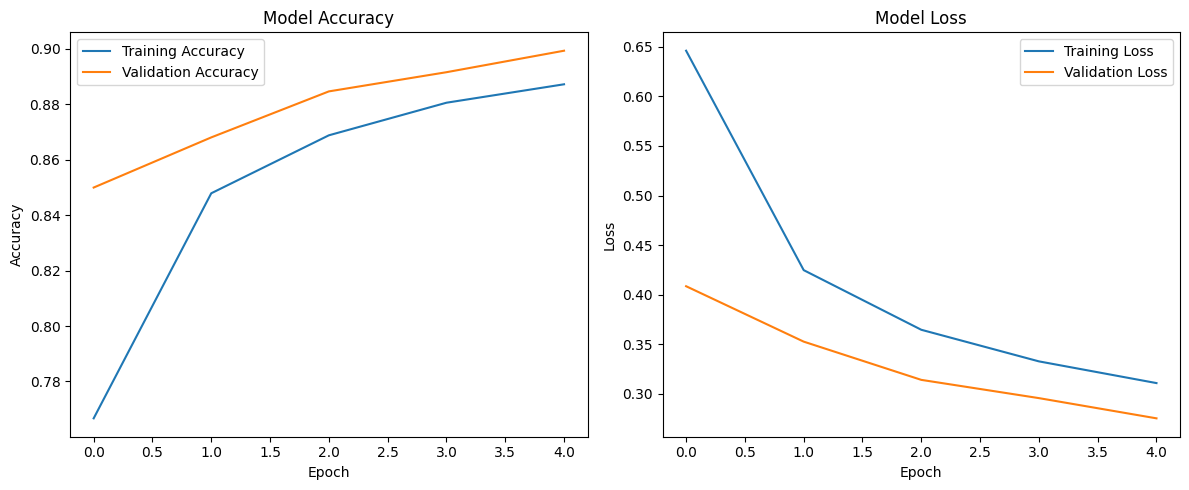

In [ ]:
# === Visualization of training ===
print("Visualizing training results...")

# Plot accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# Predict an image

In [ ]:
# === Predict from new image ===
def predict_new_image(img_path):
    model = load_model(model_path)

    img = Image.open(img_path).convert("L")
    img = ImageOps.invert(img)  # if background is white
    img = img.resize((28, 28))

    img_array = np.array(img).astype("float32") / 255.0
    img_array = img_array.reshape(1, 28, 28, 1)

    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)
    confidence = prediction[0][predicted_index]

    # Display
    plt.imshow(img, cmap='gray')
    plt.axis("off")
    plt.title(f"Prediction: {class_names[predicted_index]} ({confidence:.2%})")
    plt.show()

# === Example usage ===
# Make sure you have a .png image file (28x28 or will be resized)
# predict_new_image("fashion_mnist_images/test/Sneaker/test_0.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


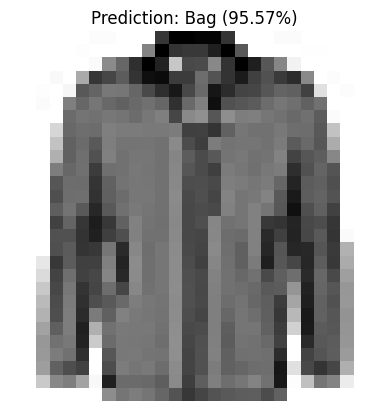

In [ ]:
predict_new_image("/content/fashion_mnist_images/test/Coat/test_1026.png")
